In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial


In [3]:
# Load the Auto dataset using ISLP's load_data function
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [4]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape #number of samples, number of features
    Yhat = estimator.predict(X) #predicted values
    RSS = np.sum((Y - Yhat)**2) #residual sum of squares
    return -(RSS + 2 * p * sigma2) / n  #return negative Cp statistic



In [5]:
# Use the Auto dataset, drop 'name' (which is the index), predict 'mpg'
design = MS(Auto.columns.drop('mpg')).fit(Auto)  # design matrix without 'mpg'
Y = np.array(Auto['mpg'])  # response vector
X = design.transform(Auto)  # design matrix as numpy array
sigma2 = OLS(Y, X).fit().scale  # estimate of error variance


In [6]:
neg_Cp = partial(nCp, sigma2) #partial function application to fix sigma2


In [7]:
from ISLP.models import Stepwise

strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms)) 

In [8]:
from ISLP.models import sklearn_selected
from statsmodels.api import OLS

auto_MSE = sklearn_selected(OLS, strategy, scoring = neg_Cp)  # use OLS as the estimator and our stepwise strategy defined above
auto_MSE.fit(X, Y)  # fit the model to the Auto data
auto_MSE.selected_state_


('origin', 'weight', 'year')

In [9]:
# Fit an OLS model using the selected variables from auto_MSE on MPG
selected_vars = auto_MSE.selected_state_
X_selected = X[list(selected_vars)]

# Ensure intercept is included
if 'intercept' not in X_selected.columns and 'intercept' in X.columns:
	X_selected = X_selected.copy()
	X_selected.insert(0, 'intercept', X['intercept'])

ols_model = OLS(Y, X_selected).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 10 Oct 2025   Prob (F-statistic):          7.26e-143
Time:                        21:02:35   Log-Likelihood:                -1027.8
No. Observations:                 392   AIC:                             2064.
Df Residuals:                     388   BIC:                             2080.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -18.0459      4.001     -4.510      0.0

In [10]:
#### Question 2  Ridge Regression

X_np = X.values  # convert DataFrame to numpy array

# Exclude the intercept column (assumed to be the first column)
X_no_intercept = X_np[:, 1:]

# Standardize features (excluding intercept)
Xs = X_no_intercept - X_no_intercept.mean(0)[None, :]
X_scale = X_no_intercept.std(0)
Xs = Xs / X_scale[None, :]

lambdas = 10**np.linspace(8, -2, 100) / Y.std()  # grid of lambda values, 100 evenly spaced on log scale, scaled by response std

soln_array = skl.ElasticNet.path(Xs,
                                 Y,
                                 l1_ratio=0.,
                                 alphas=lambdas)[1]  # get solution array for ridge regression (l1_ratio=0)
soln_array.shape  # (number of features, number of lambda values)


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.197e+05, tolerance: 2.393e+01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gr

(7, 100)

In [11]:
soln_path = pd.DataFrame(soln_array.T,
                         columns=X.columns[1:],  # use feature names (excluding intercept)
                         index=-np.log(lambdas)) #make a dataframe for easier plotting
soln_path.index.name = 'negative log(lambda)' #set index name
soln_path #display the solution path


,cylinders,displacement,horsepower,weight,acceleration,year,origin
negative log(lambda),,,,,,,
-16.367192,-4.725015e-07,-4.892170e-07,-4.729933e-07,-5.056942e-07,2.572259e-07,3.527525e-07,3.434362e-07
-16.134608,-5.962292e-07,-6.173218e-07,-5.968497e-07,-6.381137e-07,3.245822e-07,4.451231e-07,4.333673e-07
-15.902024,-7.523559e-07,-7.789716e-07,-7.531389e-07,-8.052080e-07,4.095763e-07,5.616816e-07,5.468474e-07
-15.669439,-9.493653e-07,-9.829506e-07,-9.503533e-07,-1.016057e-06,5.168265e-07,7.087618e-07,6.900431e-07
-15.436855,-1.197963e-06,-1.240343e-06,-1.199210e-06,-1.282118e-06,6.521610e-07,8.943558e-07,8.707355e-07
...,...,...,...,...,...,...,...
5.728321,-7.737033e-01,1.803298e+00,-6.870835e-01,-5.279819e+00,1.784277e-01,2.740265e+00,1.133291e+00
5.960906,-7.860061e-01,1.856653e+00,-6.798600e-01,-5.321769e+00,1.869791e-01,2.744656e+00,1.135968e+00
6.193490,-7.962989e-01,1.900312e+00,-6.740821e-01,-5.355758e+00,1.939324e-01,2.748187e+00,1.138171e+00


In [22]:
from sklearn.pipeline import Pipeline


ridge = skl.ElasticNet(alpha=lambdas[59], l1_ratio=0) #ridge regression model with lambda value from above
scaler = StandardScaler(with_mean=True,  with_std=True) #standard scaler for feature scaling
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)]) #pipeline to combine scaling and model fitting
pipe.fit(X, Y) #fit the model to the data


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.742e+03, tolerance: 2.382e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(14.079439671119571)
,l1_ratio,0
,fit_intercept,True
,precompute,False


In [23]:
validation = skm.ShuffleSplit(n_splits=1,
                              test_size=0.5,
                              random_state=0) #single 50/50 split 
ridge.alpha = 0.01 #set lambda value
results = skm.cross_validate(ridge,
                             X,
                             Y,
                             scoring='neg_mean_squared_error',
                             cv=validation) #cross-validate the model
-results['test_score'] #display the test score


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.103e+03, tolerance: 1.214e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


array([10.65267104])

In [24]:
ridge.alpha = 1e10 #set a very large lambda value
results = skm.cross_validate(ridge,
                             X,
                             Y,
                             scoring='neg_mean_squared_error',
                             cv=validation)
-results['test_score']


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.072e+03, tolerance: 1.214e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


array([59.5685548])

In [25]:
np.linalg.norm(ridge.coef_)


np.float64(0.7711465753752751)

c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.453e+03, tolerance: 1.891e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.550e+03, tolerance: 1.910e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemen

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(0....5722499704052)
,l1_ratio,0
,fit_intercept,True
,precompute,False


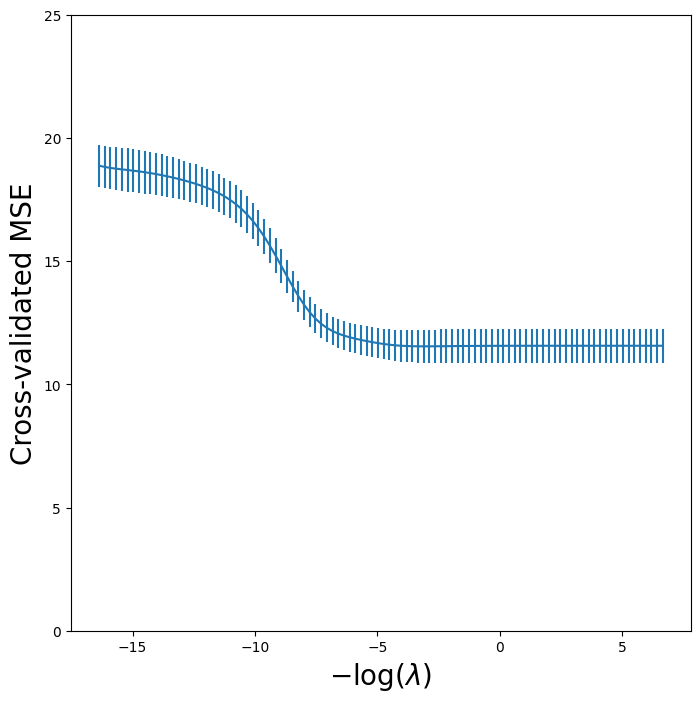

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

# Set up cross-validation
K = 5
cv = KFold(n_splits=K, shuffle=True, random_state=0)

# Ridge expects 1D array for alpha, and does not use l1_ratio
ridge_cv = Ridge()
param_grid = {'alpha': lambdas}
grid = GridSearchCV(ridge_cv, param_grid, scoring='neg_mean_squared_error', cv=cv)
grid.fit(X_no_intercept, Y)

ridge_fig, ax = subplots(figsize=(8,8)) 
ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))  #plot mean and standard error of CV MSE vs -log(lambda)
ax.set_ylim([0,25])
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);


param_grid_pipe = {'ridge__alpha': lambdas}

grid = skm.GridSearchCV(pipe, 
                        param_grid_pipe,
                        cv=cv,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

Optimal -log(lambda): 4.565399383805368
Optimal MSE: 11.493702607062664


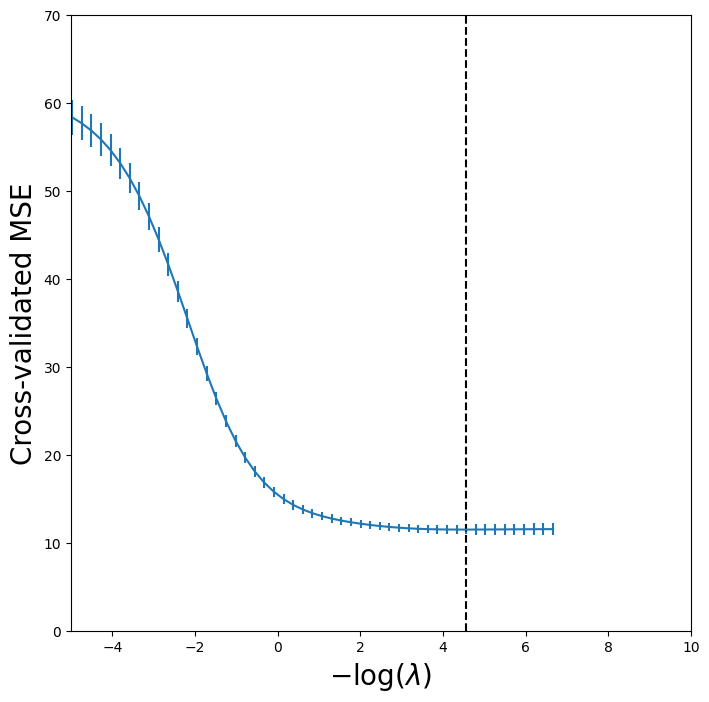

In [ ]:
tuned_ridge = grid.best_estimator_.named_steps['ridge']  # extract the fitted ridge model from the best pipeline
ridgeCV_fig, ax = subplots(figsize=(8,8))
# Note: ElasticNet does not have mse_path_ attribute like RidgeCV, so this part may not work as intended.
# If you want to plot the cross-validated MSE, use grid.cv_results_ as in cell 16:
ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.axvline(-np.log(tuned_ridge.alpha), c='k', ls='--')  # indicate chosen lambda
ax.set_ylim([0, 70])
ax.set_xlim([-5, 10])
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);


print("Optimal -log(lambda):", -np.log(tuned_ridge.alpha))
optimal_idx = np.argmin(-grid.cv_results_['mean_test_score'])
optimal_mse = -grid.cv_results_['mean_test_score'][optimal_idx]
print("Optimal MSE:", optimal_mse)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

# Split the data (exclude intercept for sklearn models)
X_train, X_test, Y_train, Y_test = train_test_split(X_no_intercept, Y, test_size=0.3, random_state=42)

# Ridge regression (use optimal alpha from grid search)
ridge = Ridge(alpha=grid.best_params_['ridge__alpha'])
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(Y_test, ridge_pred)

# OLS regression
ols = LinearRegression()
ols.fit(X_train, Y_train)
ols_pred = ols.predict(X_test)
ols_mse = mean_squared_error(Y_test, ols_pred)

print(f"Test MSE (Ridge, alpha={grid.best_params_['ridge__alpha']:.4g}): {ridge_mse:.3f}")
print(f"Test MSE (OLS): {ols_mse:.3f}")

	

#### the MSE for ridge regression is pretty much the exact same. So it doesn't improve prediction performance compared to OLS 

Test MSE (Ridge, alpha=0.01041): 10.066
Test MSE (OLS): 10.066
Ridge regression improves prediction performance compared to OLS.


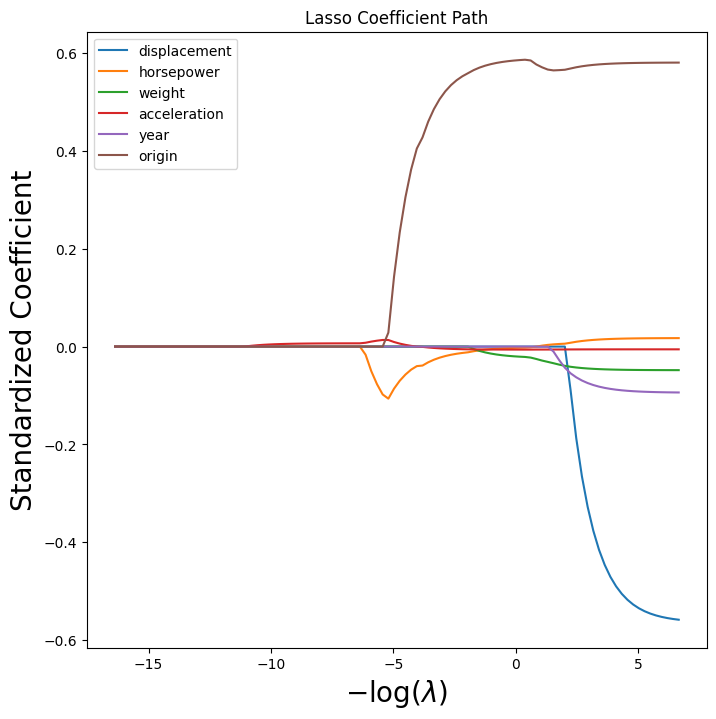

Final coefficients:
 cylinders      -0.000000
displacement    0.000000
horsepower     -0.821173
weight         -4.402397
acceleration    0.000000
year            2.590245
origin          1.150422
dtype: float64
Number of non-zero coefficients: 4
Optimal -log(lambda): 2.705
Test MSE (Lasso): 10.324
Test MSE from Ridge (Ridge, alpha=0.01041): 10.066
Test MSE for ridge is slightly lower than that of lasso, the optimal lambda for lasso is 2.7 and for ridge is 4.56


In [40]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Use the same train/test split as before
# X_train, X_test, Y_train, Y_test already defined (exclude intercept)

# Lasso regression pipeline: standardize then ElasticNetCV (Lasso)
lasso_pipe = Pipeline([
	('scaler', StandardScaler()),
	('lasso', ElasticNetCV(l1_ratio=1, alphas=lambdas, cv=5, max_iter=10000))
])
lasso_pipe.fit(X_train, Y_train)

# Get the ElasticNetCV object
lasso_cv = lasso_pipe.named_steps['lasso']

# Plot coefficient path
plt.figure(figsize=(8,8))
coefs = lasso_cv.path(X_train, Y_train, l1_ratio=1, alphas=lambdas)[1]
for i, name in enumerate(design.terms[1:]):  # exclude intercept
	plt.plot(-np.log(lambdas), coefs[i], label=name)
plt.xlabel('$-\\log(\\lambda)$', fontsize=20)
plt.ylabel('Standardized Coefficient', fontsize=20)
plt.title('Lasso Coefficient Path')
plt.legend(loc='best')
plt.show()

# Final coefficients (after standardization)
final_coefs = lasso_cv.coef_
feature_names = design.terms  # use all terms to match final_coefs length
coef_df = pd.Series(final_coefs, index=feature_names)
print("Final coefficients:\n", coef_df)

# Number of non-zero coefficients
n_nonzero = np.sum(final_coefs != 0)
print("Number of non-zero coefficients:", n_nonzero)

# Test MSE
lasso_pred = lasso_pipe.predict(X_test)
lasso_mse = mean_squared_error(Y_test, lasso_pred)
print(f"Optimal -log(lambda): {-np.log(lasso_cv.alpha_):.4g}")
print(f"Test MSE (Lasso): {lasso_mse:.3f}")
print(f"Test MSE from Ridge (Ridge, alpha={grid.best_params_['ridge__alpha']:.4g}): {ridge_mse:.3f}")
print("Test MSE for ridge is slightly lower than that of lasso, the optimal lambda for lasso is 2.7 and for ridge is 4.56")

In [54]:

from ISLP import load_data
Boston = load_data('Boston')
Boston.head()

# Split the Boston dataset into 70% training and 30% test sets (set random state to 77 for reproducibility)
from sklearn.model_selection import train_test_split
train_boston, test_boston = train_test_split(Boston, test_size=0.3, random_state=77)


In [62]:
from statsmodels.api import OLS, add_constant

# Prepare X and y for OLS using the Boston training set
X_train = train_boston.drop(columns='medv')
y_train = train_boston['medv']

# Add intercept
X_train_const = add_constant(X_train)

# Fit OLS model
ols_boston = OLS(y_train, X_train_const).fit()
print(ols_boston.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     79.05
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           9.02e-91
Time:                        21:39:40   Log-Likelihood:                -1059.8
No. Observations:                 354   AIC:                             2146.
Df Residuals:                     341   BIC:                             2196.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.8089      6.281      7.453      0.0

In [78]:
def nCp(sigma2, estimator, X_train, y_train):
    "Negative Cp statistic"
    n, p = X_train.shape #number of samples, number of features
    Yhat = estimator.predict(X_train) #predicted values
    RSS = np.sum((y_train - Yhat)**2) #residual sum of squares
    return -(RSS + 2 * p * sigma2) / n  #return negative Cp statistic

# Use the Auto dataset, drop 'name' (which is the index), predict 'mpg'  # design matrix without 'mpg' # design matrix as numpy array
sigma2 = OLS(y_train, X_train).fit().scale  # estimate of error variance

neg_Cp = partial(nCp, sigma2) #partial function application to fix sigma2



In [79]:
from ISLP.models import ModelSpec, Stepwise

# Create a ModelSpec for Boston data (excluding 'medv', which is the target)
boston_design = ModelSpec(train_boston.columns.drop('medv')).fit(train_boston)

# Stepwise strategy for Boston training data
boston_strategy = Stepwise.first_peak(
    boston_design,
    direction='forward',
    max_terms=len(boston_design.terms)
)

In [80]:

# For Auto dataset (already done above)
boston_MSE = sklearn_selected(OLS, boston_strategy, scoring=neg_Cp)  # use OLS as the estimator and our stepwise strategy defined above
boston_MSE.fit(X_train, y_train)  
print("boston selected variables:", boston_MSE.selected_state_)


boston selected variables: ('chas', 'crim', 'dis', 'lstat', 'nox', 'ptratio', 'rad', 'rm', 'tax', 'zn')


In [ ]:
b_MSE = sklearn_selected(OLS,
                               boston_strategy) #use OLS as the estimator and our stepwise strategy defined above 
b_MSE.fit(X_train, y_train) #fit the model to the data
b_MSE.selected_state_ #show which variables were selected
## just checking 

('age',
 'chas',
 'crim',
 'dis',
 'indus',
 'lstat',
 'nox',
 'ptratio',
 'rad',
 'rm',
 'tax',
 'zn')

In [90]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

# Prepare X and y for Boston training set (exclude target 'medv')
X_boston = train_boston.drop(columns='medv')
y_boston = train_boston['medv']

# Ridge regression using ElasticNetCV with l1_ratio=0 (pure ridge)
ridge_cv_pipe = Pipeline([
	('scaler', StandardScaler()),
	('ridge', ElasticNetCV(l1_ratio=0, alphas=lambdas, cv=5, max_iter=10000))
])
ridge_cv_pipe.fit(X_boston, y_boston)

# Extract the fitted ElasticNetCV object
ridge_cv = ridge_cv_pipe.named_steps['ridge']

print("Optimal alpha (lambda):", ridge_cv.alpha_)
print("Coefficients:", ridge_cv.coef_)
print("Number of non-zero coefficients:", (ridge_cv.coef_ != 0).sum())

c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.357e+04, tolerance: 2.714e+00
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gr

Optimal alpha (lambda): 0.01656885288856097
Coefficients: [-0.80329028  1.04582449 -0.12287492  1.00066552 -2.2890195   2.35863033
  0.44556422 -3.21595917  2.10027911 -1.54959245 -1.88046391 -4.48510675]
Number of non-zero coefficients: 12


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.065e+03, tolerance: 2.246e+00
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.061e+03, 

In [92]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline

# Prepare X and y for Boston training set (exclude target 'medv')
X_boston = train_boston.drop(columns='medv')
y_boston = train_boston['medv']

# Lasso regression using ElasticNetCV with l1_ratio=1 (pure lasso)
lasso_cv_pipe = Pipeline([
	('scaler', StandardScaler()),
	('lasso', ElasticNetCV(l1_ratio=1, alphas=lambdas, cv=5, max_iter=10000))
])
lasso_cv_pipe.fit(X_boston, y_boston)

# Extract the fitted ElasticNetCV object
lasso_cv = lasso_cv_pipe.named_steps['lasso']

print("Optimal alpha (lambda):", lasso_cv.alpha_)
print("Coefficients:", lasso_cv.coef_)
print("Number of non-zero coefficients:", (lasso_cv.coef_ != 0).sum())

Optimal alpha (lambda): 0.01656885288856097
Coefficients: [-8.08444321e-01  1.10465330e+00 -7.78476560e-04  9.76902396e-01
 -2.46458436e+00  2.28510931e+00  4.88897984e-01 -3.36577674e+00
  2.34829903e+00 -1.75135295e+00 -1.91688013e+00 -4.63701854e+00]
Number of non-zero coefficients: 12


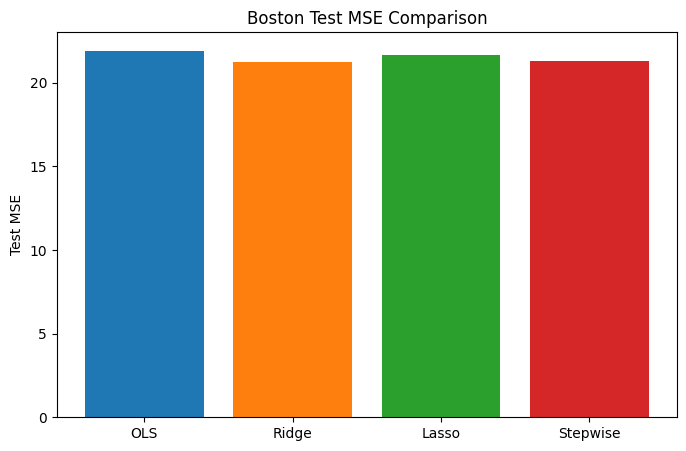

Test MSEs: {'OLS': 21.9187625937576, 'Ridge': 21.2362336033196, 'Lasso': 21.66178101784152, 'Stepwise': 21.27000838682903}
Best-performing method: Ridge (Test MSE = 21.236)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Prepare test set
X_test_boston = test_boston.drop(columns='medv')
y_test_boston = test_boston['medv']

# 1. OLS (Linear Regression)
ols_boston_pred = ols_boston.predict(add_constant(X_test_boston))
ols_boston_mse = mean_squared_error(y_test_boston, ols_boston_pred)

# 2. Ridge (ElasticNetCV with l1_ratio=0)
ridge_boston_pred = ridge_cv_pipe.predict(X_test_boston)
ridge_boston_mse = mean_squared_error(y_test_boston, ridge_boston_pred)

# 3. Lasso (ElasticNetCV with l1_ratio=1)
lasso_boston_pred = lasso_cv_pipe.predict(X_test_boston)
lasso_boston_mse = mean_squared_error(y_test_boston, lasso_boston_pred)

# 4. Stepwise (using selected variables from boston_MSE)
selected_vars = boston_MSE.selected_state_
# Prepare training and test data with intercept as first column
X_train_stepwise = add_constant(X_train[list(selected_vars)], has_constant='add')
X_test_stepwise = add_constant(X_test_boston[list(selected_vars)], has_constant='add')

ols_stepwise = OLS(y_train, X_train_stepwise).fit()
stepwise_pred = ols_stepwise.predict(X_test_stepwise)
stepwise_mse = mean_squared_error(y_test_boston, stepwise_pred)

# Collect results
mse_results = {
	'OLS': ols_boston_mse,
	'Ridge': ridge_boston_mse,
	'Lasso': lasso_boston_mse,
	'Stepwise': stepwise_mse
}

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(mse_results.keys(), mse_results.values(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.ylabel('Test MSE')
plt.title('Boston Test MSE Comparison')
plt.show()

# Identify best-performing method
best_method = min(mse_results, key=mse_results.get)
print("Test MSEs:", mse_results)
print(f"Best-performing method: {best_method} (Test MSE = {mse_results[best_method]:.3f})")


#### the lowest MSE was found to be the Ridge regression, though I would probably select stepwise in practice for interpretability, as it has a comparably low MSE but uses fewer variables.